## CROSS INDUSTRY STATISTICAL COMPARISON
**Project: Cancel Culture — Customer Churn Analysis,
 Comparing: Telco vs Banking**

In [1]:
# CELL 1 — IMPORT LIBRARIES AND LOAD BOTH DATASETS
# Loads all statistical tools and both clean datasets
# ============================================================
 
%matplotlib inline
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style="whitegrid")
 
# Load both datasets
project_path = '/Users/hinahaq/Downloads/Final_Project/clean_data/'
 
df_telco = pd.read_csv(project_path + 'Telco_Customer_churn_cleaned.csv')
df_bank = pd.read_csv(project_path + 'bank_churn_cleaned.csv')
 
# Quick confirmation
print(f"Telco loaded: {df_telco.shape[0]} rows | Churn rate: {df_telco['Churn_Binary'].mean()*100:.1f}%")
print(f"Bank loaded:  {df_bank.shape[0]} rows | Churn rate: {df_bank['Churn_Binary'].mean()*100:.1f}%")
 

Telco loaded: 7032 rows | Churn rate: 26.6%
Bank loaded:  10000 rows | Churn rate: 20.4%


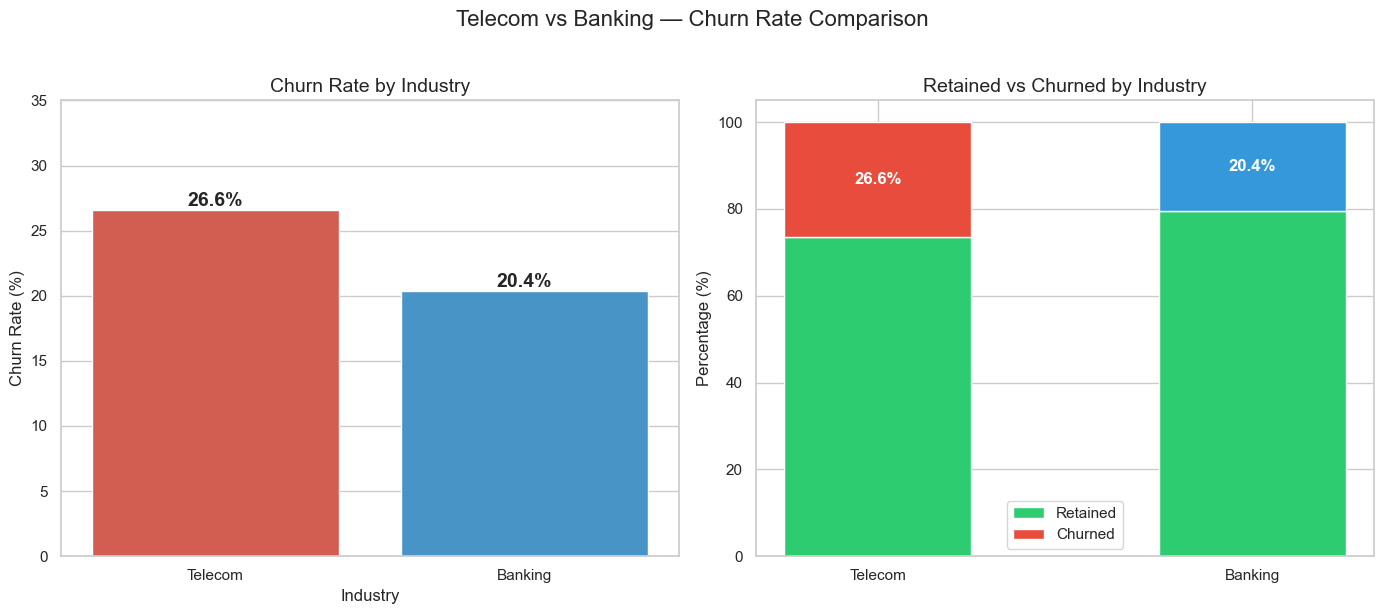

 Cell 2 complete — Churn Rate Comparison Chart


In [ ]:
# CELL 2 — SIDE BY SIDE CHURN RATE COMPARISON
# Visual comparison of overall churn and retainedrates
# ============================================================
 
comparison_data = pd.DataFrame({
    'Industry': ['Telecom', 'Banking'],
    'Churn_Rate': [
        df_telco['Churn_Binary'].mean() * 100,
        df_bank['Churn_Binary'].mean() * 100
    ],
    'Retained_Rate': [
        (1 - df_telco['Churn_Binary'].mean()) * 100,
        (1 - df_bank['Churn_Binary'].mean()) * 100
    ]
})
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Chart 1 — Churn rate comparison
bars = sns.barplot(data=comparison_data, x='Industry', y='Churn_Rate',
                   hue='Industry',
                   palette={'Telecom': '#e74c3c', 'Banking': '#3498db'},
                   legend=False, ax=axes[0])
axes[0].set_title('Churn Rate by Industry', fontsize=14)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 35)
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=14, fontweight='bold')
 
# Chart 2 — Stacked bar showing retained vs churned
x = np.arange(2)
width = 0.5
axes[1].bar(x, comparison_data['Retained_Rate'],
            width, label='Retained', color=['#2ecc71', '#2ecc71'])
axes[1].bar(x, comparison_data['Churn_Rate'],
            width, bottom=comparison_data['Retained_Rate'],
            label='Churned', color=['#e74c3c', '#3498db'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Telecom', 'Banking'])
axes[1].set_title('Retained vs Churned by Industry', fontsize=14)
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()
for i, (ret, churn) in enumerate(zip(comparison_data['Retained_Rate'],
                                      comparison_data['Churn_Rate'])):
    axes[1].text(i, ret + churn/2, f'{churn:.1f}%',
                 ha='center', va='center', fontsize=12,
                 fontweight='bold', color='white')
 
plt.suptitle('Telecom vs Banking — Churn Rate Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'comparison_01_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cell 2 complete — Churn Rate Comparison Chart")
 
 

In [ ]:
# CELL 3 — Z-TEST: IS THE CHURN RATE DIFFERENCE SIGNIFICANT?
# ============================================================
 
print("=" * 55)
print("   TEST 1 — Z-TEST: CHURN RATE COMPARISON")
print("   Telco (26.6%) vs Banking (20.4%)")
print("=" * 55)
 
# Get churn counts
telco_churned = df_telco['Churn_Binary'].sum()
telco_total = len(df_telco)
bank_churned = df_bank['Churn_Binary'].sum()
bank_total = len(df_bank)
 
telco_rate = telco_churned / telco_total
bank_rate = bank_churned / bank_total
 
# Pooled proportion
pooled = (telco_churned + bank_churned) / (telco_total + bank_total)
 
# Z-score calculation
se = np.sqrt(pooled * (1 - pooled) * (1/telco_total + 1/bank_total))
z_score = (telco_rate - bank_rate) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
 
print(f"\nTelco churn rate:   {telco_rate*100:.2f}%  ({telco_churned}/{telco_total})")
print(f"Banking churn rate: {bank_rate*100:.2f}%  ({bank_churned}/{bank_total})")
print(f"\nZ-score:  {z_score:.4f}")
print(f"P-value:  {p_value:.6f}")
print(f"\nResult: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'}")
print(f"Interpretation: The difference in churn rates between")
print(f"Telecom and Banking IS {'statistically significant' if p_value < 0.05 else 'NOT statistically significant'}.")
print(f"(p {'< 0.05' if p_value < 0.05 else '> 0.05'})")
print("=" * 55)
 
 

   TEST 1 — Z-TEST: CHURN RATE COMPARISON
   Telco (26.6%) vs Banking (20.4%)

Telco churn rate:   26.58%  (1869/7032)
Banking churn rate: 20.37%  (2037/10000)

Z-score:  9.4891
P-value:  0.000000

Result: SIGNIFICANT
Interpretation: The difference in churn rates between
Telecom and Banking IS statistically significant.
(p < 0.05)


In [8]:
# CELL 4 — T-TEST: DO CHURNERS PAY MORE THAN STAYERS?
# Tests whether churners have significantly higher charges in both industries
# ============================================================
 
print("=" * 55)
print("   TEST 2 — T-TEST: CHARGES — CHURNERS VS STAYERS")
print("=" * 55)
 
# --- TELCO ---
telco_churned_charges = df_telco[df_telco['Churn_Binary']==1]['MonthlyCharges']
telco_stayed_charges = df_telco[df_telco['Churn_Binary']==0]['MonthlyCharges']
t_stat_telco, p_telco = ttest_ind(telco_churned_charges, telco_stayed_charges)
 
print(f"\n📡 TELECOM — Monthly Charges")
print(f"Churners avg:  ${telco_churned_charges.mean():.2f}")
print(f"Stayers avg:   ${telco_stayed_charges.mean():.2f}")
print(f"Difference:    ${telco_churned_charges.mean() - telco_stayed_charges.mean():.2f}")
print(f"T-statistic:   {t_stat_telco:.4f}")
print(f"P-value:       {p_telco:.6f}")
print(f"Result: {'SIGNIFICANT' if p_telco < 0.05 else 'NOT SIGNIFICANT'}")
 
# --- BANK ---
bank_churned_balance = df_bank[df_bank['Churn_Binary']==1]['Balance']
bank_stayed_balance = df_bank[df_bank['Churn_Binary']==0]['Balance']
t_stat_bank, p_bank = ttest_ind(bank_churned_balance, bank_stayed_balance)
 
print(f"\nBANKING — Account Balance")
print(f"Churners avg:  ${bank_churned_balance.mean():,.0f}")
print(f"Stayers avg:   ${bank_stayed_balance.mean():,.0f}")
print(f"Difference:    ${bank_churned_balance.mean() - bank_stayed_balance.mean():,.0f}")
print(f"T-statistic:   {t_stat_bank:.4f}")
print(f"P-value:       {p_bank:.6f}")
print(f"Result: {'SIGNIFICANT' if p_bank < 0.05 else 'NOT SIGNIFICANT'}")
print("=" * 55)
 

   TEST 2 — T-TEST: CHARGES — CHURNERS VS STAYERS

📡 TELECOM — Monthly Charges
Churners avg:  $74.44
Stayers avg:   $61.31
Difference:    $13.13
T-statistic:   16.4796
P-value:       0.000000
Result: SIGNIFICANT

BANKING — Account Balance
Churners avg:  $91,109
Stayers avg:   $72,745
Difference:    $18,363
T-statistic:   11.9362
P-value:       0.000000
Result: SIGNIFICANT


In [11]:
# CELL 5 — CHI-SQUARE TEST: CATEGORICAL VARIABLES VS CHURN
# Tests whether categorical variables are genuinely associated with churn or just random patterns
# We test the strongest predictor in each dataset
# ============================================================
 
print("=" * 55)
print("   TEST 3 — CHI-SQUARE: CATEGORICAL VS CHURN")
print("=" * 55)
 
# --- TELCO: Contract Type vs Churn ---
telco_contingency = pd.crosstab(df_telco['Contract'],
                                 df_telco['Churn_Binary'])
chi2_telco, p_telco_chi, dof_telco, _ = chi2_contingency(telco_contingency)
 
print(f"\nTELECOM — Contract Type vs Churn")
print(f"Chi-square statistic: {chi2_telco:.4f}")
print(f"Degrees of freedom:   {dof_telco}")
print(f"P-value:              {p_telco_chi:.10f}")
print(f"Result: {'SIGNIFICANT' if p_telco_chi < 0.05 else 'NOT SIGNIFICANT'}")
 
# --- BANK: Geography vs Churn ---
bank_contingency = pd.crosstab(df_bank['Geography'],
                                df_bank['Churn_Binary'])
chi2_bank, p_bank_chi, dof_bank, _ = chi2_contingency(bank_contingency)
 
print(f"\nBANKING — Geography vs Churn")
print(f"Chi-square statistic: {chi2_bank:.4f}")
print(f"Degrees of freedom:   {dof_bank}")
print(f"P-value:              {p_bank_chi:.10f}")
print(f"Result: {'SIGNIFICANT' if p_bank_chi < 0.05 else 'NOT SIGNIFICANT'}")
 
# --- BANK: Gender vs Churn ---
bank_gender_contingency = pd.crosstab(df_bank['Gender'],
                                       df_bank['Churn_Binary'])
chi2_gender, p_gender_chi, dof_gender, _ = chi2_contingency(bank_gender_contingency)
 
print(f"\nBANKING — Gender vs Churn")
print(f"Chi-square statistic: {chi2_gender:.4f}")
print(f"Degrees of freedom:   {dof_gender}")
print(f"P-value:              {p_gender_chi:.10f}")
print(f"Result: {'SIGNIFICANT' if p_gender_chi < 0.05 else 'NOT SIGNIFICANT'}")
print("=" * 55)


   TEST 3 — CHI-SQUARE: CATEGORICAL VS CHURN

TELECOM — Contract Type vs Churn
Chi-square statistic: 1179.5458
Degrees of freedom:   2
P-value:              0.0000000000
Result: SIGNIFICANT

BANKING — Geography vs Churn
Chi-square statistic: 301.2553
Degrees of freedom:   2
P-value:              0.0000000000
Result: SIGNIFICANT

BANKING — Gender vs Churn
Chi-square statistic: 112.9186
Degrees of freedom:   1
P-value:              0.0000000000
Result: SIGNIFICANT


In [ ]:
# CELL 6 — CORRELATION ANALYSIS: TENURE VS CHURN
# Compares how strongly tenure predicts churn in Telco vs Banking
# ============================================================
 
print("=" * 55)
print("   TEST 4 — CORRELATION: TENURE VS CHURN")
print("=" * 55)
 
# Telco tenure correlation
telco_corr, telco_corr_p = pointbiserialr(df_telco['tenure'],
                                           df_telco['Churn_Binary'])
 
print(f"\nTELECOM — Tenure vs Churn")
print(f"Correlation (r):  {telco_corr:.4f}")
print(f"P-value:          {telco_corr_p:.10f}")
print(f"Result: {'SIGNIFICANT' if telco_corr_p < 0.05 else ' NOT SIGNIFICANT'}")
print(f"Meaning: {'Longer tenure strongly REDUCES churn' if telco_corr < -0.1 else 'Weak relationship'}")
 
# Bank tenure correlation
bank_corr, bank_corr_p = pointbiserialr(df_bank['Tenure'],
                                         df_bank['Churn_Binary'])
 
print(f"\nBANKING — Tenure vs Churn")
print(f"Correlation (r):  {bank_corr:.4f}")
print(f"P-value:          {bank_corr_p:.10f}")
print(f"Result: {'SIGNIFICANT' if bank_corr_p < 0.05 else 'NOT SIGNIFICANT'}")
print(f"Meaning: {'Tenure affects churn' if abs(bank_corr) > 0.1 else 'Tenure has almost NO effect on bank churn'}")
 
print(f"\nCOMPARISON SUMMARY:")
print(f"Telco r = {telco_corr:.4f} → tenure is a STRONG churn predictor")
print(f"Bank  r = {bank_corr:.4f}  → tenure is NOT a churn predictor")
print("=" * 55)
 

   TEST 4 — CORRELATION: TENURE VS CHURN

TELECOM — Tenure vs Churn
Correlation (r):  -0.3540
P-value:          0.0000000000
Result: SIGNIFICANT
Meaning: Longer tenure strongly REDUCES churn

BANKING — Tenure vs Churn
Correlation (r):  -0.0140
P-value:          0.1615268495
Result: NOT SIGNIFICANT
Meaning: Tenure has almost NO effect on bank churn

COMPARISON SUMMARY:
Telco r = -0.3540 → tenure is a STRONG churn predictor
Bank  r = -0.0140  → tenure is NOT a churn predictor


In [15]:
# CELL 7 — EFFECT SIZE: COHEN'S D
# Statistical significance tells us IF a difference exists
# Effect size tells us HOW BIG that difference is
# Small: d < 0.2 | Medium: 0.2-0.5 | Large: d > 0.8
# ============================================================
 
print("=" * 55)
print("   TEST 5 — EFFECT SIZE: COHEN'S D")
print("=" * 55)
 
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std
 
def interpret_d(d):
    d = abs(d)
    if d < 0.2: return "Negligible"
    elif d < 0.5: return "Small"
    elif d < 0.8: return "Medium"
    else: return "Large"
 
# Telco — tenure effect
telco_churned_tenure = df_telco[df_telco['Churn_Binary']==1]['tenure']
telco_stayed_tenure = df_telco[df_telco['Churn_Binary']==0]['tenure']
d_telco_tenure = cohens_d(telco_churned_tenure, telco_stayed_tenure)
 
print(f"\nTELECOM — Tenure difference (churned vs stayed)")
print(f"Churners avg tenure: {telco_churned_tenure.mean():.1f} months")
print(f"Stayers avg tenure:  {telco_stayed_tenure.mean():.1f} months")
print(f"Cohen's d: {d_telco_tenure:.4f} → {interpret_d(d_telco_tenure)} effect")
 
# Bank — age effect
bank_churned_age = df_bank[df_bank['Churn_Binary']==1]['Age']
bank_stayed_age = df_bank[df_bank['Churn_Binary']==0]['Age']
d_bank_age = cohens_d(bank_churned_age, bank_stayed_age)
 
print(f"\nBANKING — Age difference (churned vs stayed)")
print(f"Churners avg age: {bank_churned_age.mean():.1f} years")
print(f"Stayers avg age:  {bank_stayed_age.mean():.1f} years")
print(f"Cohen's d: {d_bank_age:.4f} → {interpret_d(d_bank_age)} effect")
 
# Telco — monthly charges effect
d_telco_charges = cohens_d(telco_churned_charges, telco_stayed_charges)
print(f"\nTELECOM — Monthly charges difference")
print(f"Cohen's d: {d_telco_charges:.4f} → {interpret_d(d_telco_charges)} effect")
 
# Bank — balance effect
d_bank_balance = cohens_d(bank_churned_balance, bank_stayed_balance)
print(f"\nBANKING — Balance difference")
print(f"Cohen's d: {d_bank_balance:.4f} → {interpret_d(d_bank_balance)} effect")
print("=" * 55)
 
 

   TEST 5 — EFFECT SIZE: COHEN'S D

TELECOM — Tenure difference (churned vs stayed)
Churners avg tenure: 18.0 months
Stayers avg tenure:  37.7 months
Cohen's d: -0.8569 → Large effect

BANKING — Age difference (churned vs stayed)
Churners avg age: 44.8 years
Stayers avg age:  37.4 years
Cohen's d: 0.7391 → Medium effect

TELECOM — Monthly charges difference
Cohen's d: 0.4449 → Small effect

BANKING — Balance difference
Cohen's d: 0.2964 → Small effect


In [16]:
# CELL 8 — FULL STATISTICAL SUMMARY TABLE
# Collects all test results into one clean summary
# ============================================================
 
print("\n")
print("=" * 70)
print("         COMPLETE STATISTICAL SUMMARY — SAVE THIS")
print("=" * 70)
print(f"{'Test':<35} {'Statistic':>12} {'P-value':>12} {'Result':>12}")
print("-" * 70)
 
# Z-test
print(f"{'Z-test: Telco vs Bank churn rate':<35} {'z='+str(round(z_score,3)):>12} {round(p_value,6):>12} {'SIG' if p_value < 0.05 else 'NS':>12}")
 
# T-tests
print(f"{'T-test: Telco charges churned/stayed':<35} {'t='+str(round(t_stat_telco,3)):>12} {round(p_telco,6):>12} {'SIG' if p_telco < 0.05 else 'NS':>12}")
print(f"{'T-test: Bank balance churned/stayed':<35} {'t='+str(round(t_stat_bank,3)):>12} {round(p_bank,6):>12} {'SIG' if p_bank < 0.05 else 'NS':>12}")
 
# Chi-square
print(f"{'Chi2: Telco contract vs churn':<35} {'χ²='+str(round(chi2_telco,1)):>12} {'<0.0001':>12} {'SIG':>12}")
print(f"{'Chi2: Bank geography vs churn':<35} {'χ²='+str(round(chi2_bank,1)):>12} {'<0.0001':>12} {'SIG':>12}")
print(f"{'Chi2: Bank gender vs churn':<35} {'χ²='+str(round(chi2_gender,1)):>12} {'<0.0001':>12} {'SIG':>12}")
 
# Correlations
print(f"{'Corr: Telco tenure vs churn':<35} {'r='+str(round(telco_corr,4)):>12} {'<0.0001':>12} {'SIG':>12}")
print(f"{'Corr: Bank tenure vs churn':<35} {'r='+str(round(bank_corr,4)):>12} {round(bank_corr_p,4):>12} {'SIG' if bank_corr_p < 0.05 else 'NS':>12}")
 
# Effect sizes
print(f"\n{'Effect Size (Cohen d)':<35} {'Value':>12} {'':>12} {'Size':>12}")
print("-" * 70)
print(f"{'Telco: tenure churned vs stayed':<35} {'d='+str(round(d_telco_tenure,3)):>12} {'':>12} {interpret_d(d_telco_tenure):>12}")
print(f"{'Bank: age churned vs stayed':<35} {'d='+str(round(d_bank_age,3)):>12} {'':>12} {interpret_d(d_bank_age):>12}")
print(f"{'Telco: charges churned vs stayed':<35} {'d='+str(round(d_telco_charges,3)):>12} {'':>12} {interpret_d(d_telco_charges):>12}")
print(f"{'Bank: balance churned vs stayed':<35} {'d='+str(round(d_bank_balance,3)):>12} {'':>12} {interpret_d(d_bank_balance):>12}")
print("=" * 70)
print("\nSTATISTICAL ANALYSIS COMPLETE!")
 
 




         COMPLETE STATISTICAL SUMMARY — SAVE THIS
Test                                   Statistic      P-value       Result
----------------------------------------------------------------------
Z-test: Telco vs Bank churn rate         z=9.489          0.0          SIG
T-test: Telco charges churned/stayed      t=16.48          0.0          SIG
T-test: Bank balance churned/stayed     t=11.936          0.0          SIG
Chi2: Telco contract vs churn          χ²=1179.5      <0.0001          SIG
Chi2: Bank geography vs churn           χ²=301.3      <0.0001          SIG
Chi2: Bank gender vs churn              χ²=112.9      <0.0001          SIG
Corr: Telco tenure vs churn             r=-0.354      <0.0001          SIG
Corr: Bank tenure vs churn              r=-0.014       0.1615           NS

Effect Size (Cohen d)                      Value                      Size
----------------------------------------------------------------------
Telco: tenure churned vs stayed         d=-0.857      

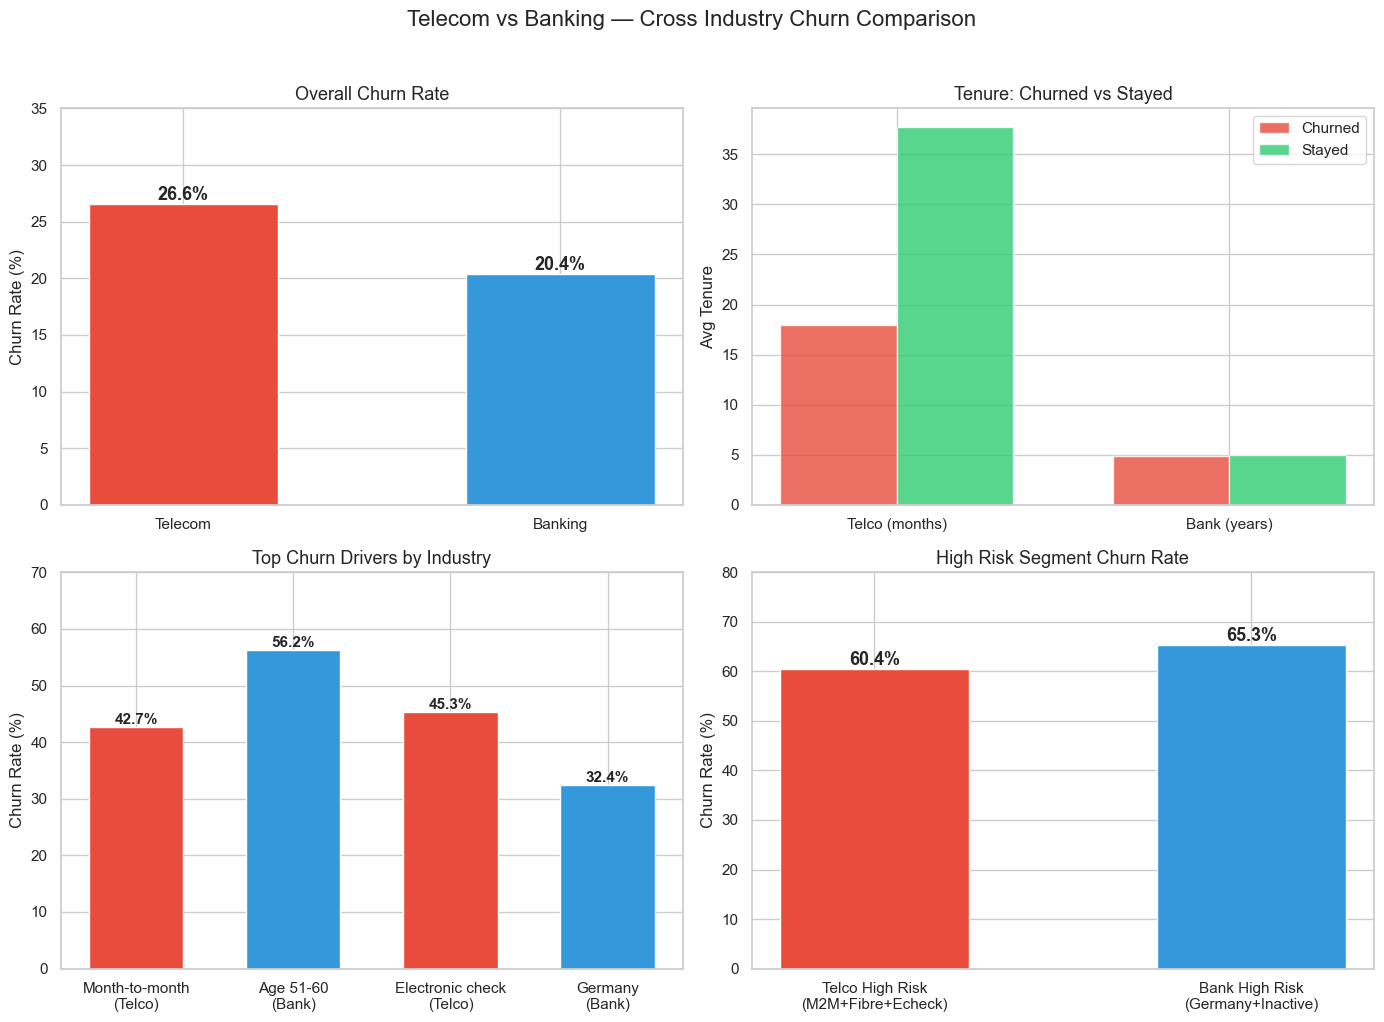

complete — Cross Industry Comparison Chart


In [17]:
# CELL 9 — CROSS INDUSTRY COMPARISON VISUAL SUMMARY
# Side by side comparison of key churn drivers
# ============================================================
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# Chart 1 — Churn rate by industry
industries = ['Telecom', 'Banking']
churn_rates = [26.6, 20.4]
colors = ['#e74c3c', '#3498db']
bars = axes[0,0].bar(industries, churn_rates, color=colors, width=0.5)
axes[0,0].set_title('Overall Churn Rate', fontsize=13)
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].set_ylim(0, 35)
for bar, rate in zip(bars, churn_rates):
    axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{rate}%', ha='center', va='bottom',
                   fontsize=13, fontweight='bold')
 
# Chart 2 — Tenure effect comparison
tenure_data = pd.DataFrame({
    'Group': ['Churned', 'Stayed', 'Churned', 'Stayed'],
    'Industry': ['Telecom', 'Telecom', 'Banking', 'Banking'],
    'Value': [18.0, 37.7, 4.9, 5.0],
    'Unit': ['months', 'months', 'years', 'years']
})
x = np.arange(2)
width = 0.35
axes[0,1].bar(x - width/2, [18.0, 4.9], width,
              label='Churned', color='#e74c3c', alpha=0.8)
axes[0,1].bar(x + width/2, [37.7, 5.0], width,
              label='Stayed', color='#2ecc71', alpha=0.8)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(['Telco (months)', 'Bank (years)'])
axes[0,1].set_title('Tenure: Churned vs Stayed', fontsize=13)
axes[0,1].legend()
axes[0,1].set_ylabel('Avg Tenure')
 
# Chart 3 — Top churn driver by industry
drivers = ['Month-to-month\n(Telco)', 'Age 51-60\n(Bank)',
           'Electronic check\n(Telco)', 'Germany\n(Bank)']
rates = [42.7, 56.2, 45.3, 32.4]
driver_colors = ['#e74c3c', '#3498db', '#e74c3c', '#3498db']
bars3 = axes[1,0].bar(drivers, rates, color=driver_colors, width=0.6)
axes[1,0].set_title('Top Churn Drivers by Industry', fontsize=13)
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].set_ylim(0, 70)
for bar, rate in zip(bars3, rates):
    axes[1,0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{rate}%', ha='center', va='bottom', fontsize=11,
                   fontweight='bold')
 
# Chart 4 — High risk segments
segments = ['Telco High Risk\n(M2M+Fibre+Echeck)', 'Bank High Risk\n(Germany+Inactive)']
risk_rates = [60.4, 65.3]
risk_colors = ['#e74c3c', '#3498db']
bars4 = axes[1,1].bar(segments, risk_rates, color=risk_colors, width=0.5)
axes[1,1].set_title('High Risk Segment Churn Rate', fontsize=13)
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].set_ylim(0, 80)
for bar, rate in zip(bars4, risk_rates):
    axes[1,1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{rate}%', ha='center', va='bottom',
                   fontsize=13, fontweight='bold')
 
plt.suptitle('Telecom vs Banking — Cross Industry Churn Comparison',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'comparison_02_cross_industry_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("complete — Cross Industry Comparison Chart")

 